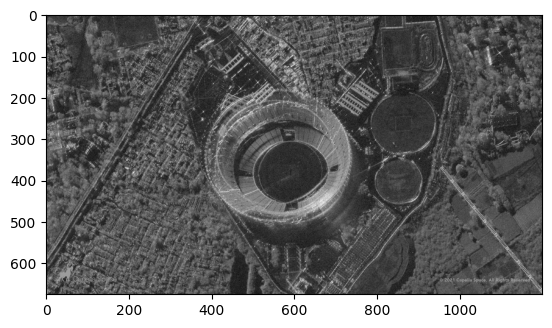

In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [36]:
def evaluate(original, filtered, name=""):
    mse = mean_squared_error(original, filtered)
    (ssim, _) = structural_similarity(original, filtered, full=True)
    print(f"{name:35s} | MSE = {mse:10.3f} | SSIM = {ssim:.4f}")
    return mse, ssim

Gaussian noise                      | MSE =   4226.025 | SSIM = 0.1873


(np.float64(4226.025272839506), np.float64(0.18728917567733971))

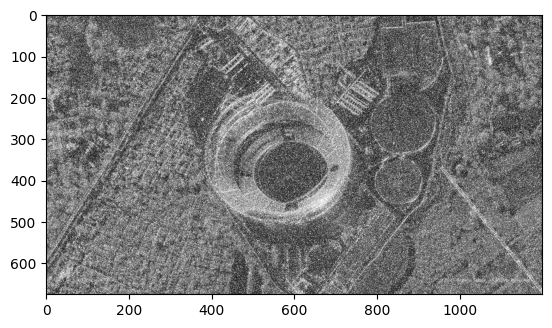

In [37]:
# Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")
evaluate(image_gray, image_noise_gauss, "Gaussian noise")

Salt & pepper noise                 | MSE =    393.225 | SSIM = 0.7183


(np.float64(393.2246037037037), np.float64(0.7183167244921298))

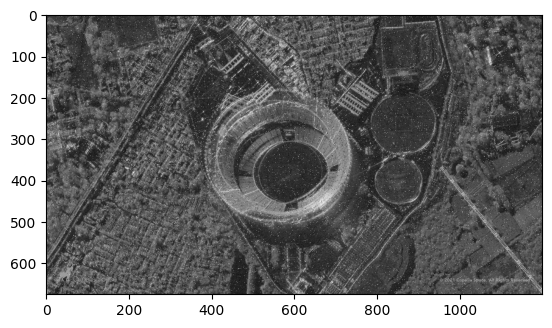

In [38]:
# Постоянный
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")
evaluate(image_gray, image_sp, "Salt & pepper noise")

In [39]:
# Задание 2
for k in [3, 5, 7]:
    img_med = cv2.medianBlur(image_noise_gauss, k)
    evaluate(image_gray, img_med, f"Gauss + medianBlur k={k}")


for k in [(3, 3), (5, 5), (7, 7)]:
    img_g = cv2.GaussianBlur(image_noise_gauss, k, 0)
    evaluate(image_gray, img_g, f"Gauss + GaussianBlur {k}")

for sigma in [10, 30, 50]:
    img_g = cv2.GaussianBlur(image_noise_gauss, (5, 5), sigma)
    evaluate(image_gray, img_g, f"Gauss + GaussianBlur sigma={sigma}")


for d, sc, ss in [(5, 30, 30), (9, 75, 75), (9, 150, 150), (15, 200, 200)]:
    img_b = cv2.bilateralFilter(image_noise_gauss, d, sc, ss)
    evaluate(image_gray, img_b, f"Gauss + bilateral d={d},sc={sc},ss={ss}")


for h in [5, 10, 20, 30]:
    img_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    evaluate(image_gray, img_nlm, f"Gauss + NLM h={h}")

Gauss + medianBlur k=3              | MSE =   1035.580 | SSIM = 0.4294
Gauss + medianBlur k=5              | MSE =    704.636 | SSIM = 0.4706
Gauss + medianBlur k=7              | MSE =    680.358 | SSIM = 0.4341
Gauss + GaussianBlur (3, 3)         | MSE =   1900.514 | SSIM = 0.4409
Gauss + GaussianBlur (5, 5)         | MSE =   1761.808 | SSIM = 0.4866
Gauss + GaussianBlur (7, 7)         | MSE =   1718.326 | SSIM = 0.4934
Gauss + GaussianBlur sigma=10       | MSE =   1752.003 | SSIM = 0.4413
Gauss + GaussianBlur sigma=30       | MSE =   1752.003 | SSIM = 0.4413
Gauss + GaussianBlur sigma=50       | MSE =   1752.003 | SSIM = 0.4413
Gauss + bilateral d=5,sc=30,ss=30   | MSE =   3702.087 | SSIM = 0.1904
Gauss + bilateral d=9,sc=75,ss=75   | MSE =   1835.840 | SSIM = 0.3151
Gauss + bilateral d=9,sc=150,ss=150 | MSE =   1545.784 | SSIM = 0.4419
Gauss + bilateral d=15,sc=200,ss=200 | MSE =   1668.742 | SSIM = 0.3551
Gauss + NLM h=5                     | MSE =   4226.025 | SSIM = 0.1873
Gauss

In [40]:

for k in [3, 5, 7]:
    img_med = cv2.medianBlur(image_sp, k)
    evaluate(image_gray, img_med, f"S&P + medianBlur k={k}")


img_g = cv2.GaussianBlur(image_sp, (5, 5), 0)
evaluate(image_gray, img_g, "S&P + GaussianBlur 5x5")


img_b = cv2.bilateralFilter(image_sp, 9, 75, 75)
evaluate(image_gray, img_b, "S&P + bilateral 9,75,75")

img_nlm = cv2.fastNlMeansDenoising(image_sp, h=20)
evaluate(image_gray, img_nlm, "S&P + NLM h=20")

S&P + medianBlur k=3                | MSE =     95.888 | SSIM = 0.8162
S&P + medianBlur k=5                | MSE =    194.336 | SSIM = 0.6329
S&P + medianBlur k=7                | MSE =    260.200 | SSIM = 0.5222
S&P + GaussianBlur 5x5              | MSE =    143.343 | SSIM = 0.7341
S&P + bilateral 9,75,75             | MSE =    267.266 | SSIM = 0.5189
S&P + NLM h=20                      | MSE =    223.165 | SSIM = 0.5919


(np.float64(223.16506913580247), np.float64(0.5919206790894315))

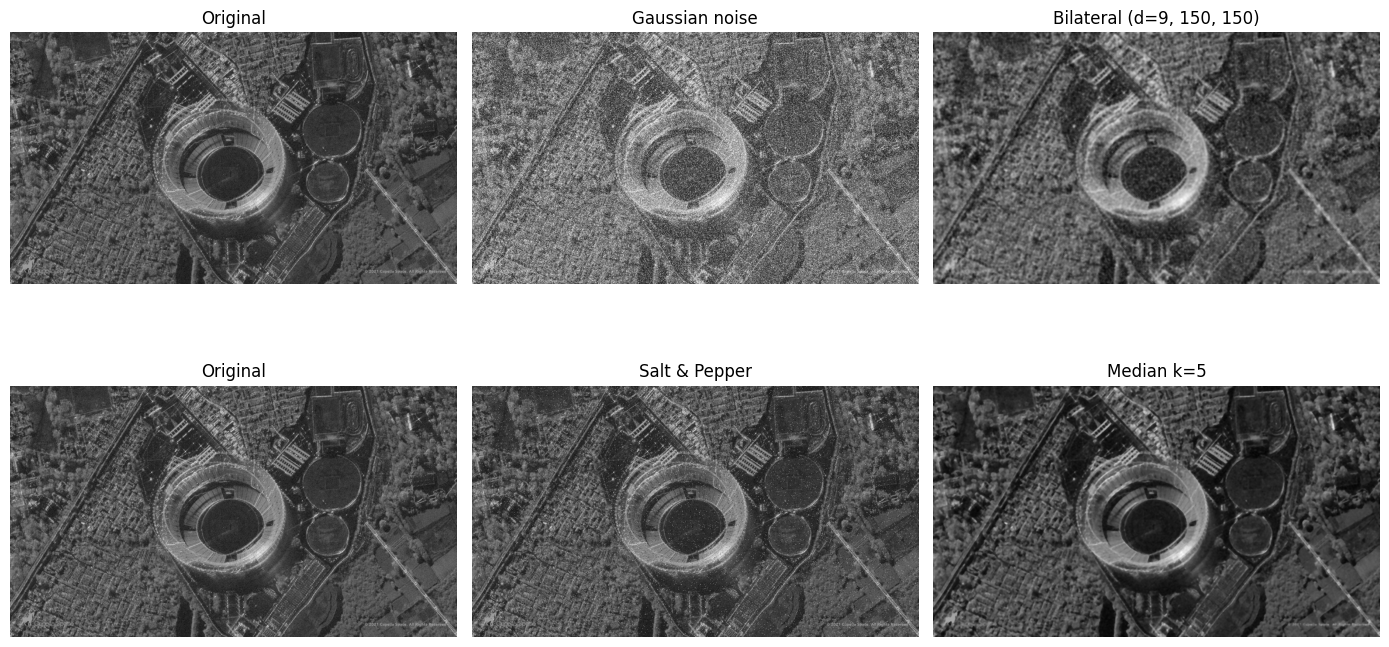

In [41]:
# Задание 3
best_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)
best_sp = cv2.medianBlur(image_sp, 5)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(image_gray, cmap="gray"); axes[0, 0].set_title("Original")
axes[0, 1].imshow(image_noise_gauss, cmap="gray"); axes[0, 1].set_title("Gaussian noise")
axes[0, 2].imshow(best_gauss, cmap="gray"); axes[0, 2].set_title("Bilateral (d=9, 150, 150)")
axes[1, 0].imshow(image_gray, cmap="gray"); axes[1, 0].set_title("Original")
axes[1, 1].imshow(image_sp, cmap="gray"); axes[1, 1].set_title("Salt & Pepper")
axes[1, 2].imshow(best_sp, cmap="gray"); axes[1, 2].set_title("Median k=5")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

Для гауссова шума наилучший результат показали билатеральный фильтр и фильтр нелокальных средних
Для шума соль и перец лучше всего подходит медианный фильтр